In [1]:
from langgraph.graph import START, END, StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from my_project.rag.core.schemas import ChatbotState, TriageResult
from my_project.rag.core.prompts import general_answer_prompt,answer_prompt, triage_prompt
from my_project.rag.core.config import settings
from my_project.rag.load_retrieve.retriever import get_retriever
from my_project.rag.core.sqlite_checkpointer import get_checkpointer
from dotenv import load_dotenv
load_dotenv()


model1 = ChatGoogleGenerativeAI(model = settings.GOOGLE_MODEL_LITE)
model2 = ChatGoogleGenerativeAI(model = settings.GOOGLE_MODEL_HEAVY)
retriever = get_retriever()
triage_model = model1.with_structured_output(TriageResult)

e:\Projects\Customer_Support_Chatbot\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8019.26it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
# Functions/ Nodes 
def TriageNode(state: ChatbotState):
    chain = triage_prompt | triage_model
    result = chain.invoke({
        "query": state.query,
        "chat_history": state.chat_history[-4:] if state.chat_history else []
    })

    return {
        "persona": result.persona,
        "persona_confidence": result.confidence,
        "escalate": result.escalate,
        "retrieval_required": result.retrieval_required
    }

def HumanSupport(state: ChatbotState):
    return {"answer": "Your issue has been escalated to a human support agent."}

def MainRouter(state : ChatbotState):
    if state.escalate:
        return "HumanSupport"
    elif state.retrieval_required:
        return "Retrieve"
    else:
        return "GeneralAnswer"
    
def Retrieve(state : ChatbotState):
    docs = retriever.invoke(state.query)
    return {'docs':docs}

def GeneralAnswer(state : ChatbotState):
    chain = general_answer_prompt | model1 
    result = chain.invoke({
        'persona' : state.persona,
        'query' : state.query,
        'chat_history' : state.chat_history[-2:] if state.chat_history else []
    })
    return {'general_answer':result.content,'chat_history':[result]}

def Answer(state : ChatbotState):
    chain = answer_prompt | model2
    context = "\n\n".join(doc.page_content for doc in state.docs)
    result = chain.invoke({
        'context' : context,
        'persona' : state.persona,
        'query' : state.query,
        'chat_history' : state.chat_history[-4:] if state.chat_history else []
    }) 
    return {'answer':result.content,'chat_history':[result]}

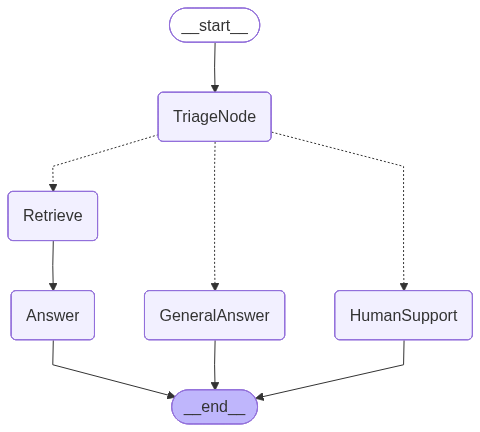

In [3]:
graph = StateGraph(ChatbotState)

graph.add_node("TriageNode",TriageNode)
graph.add_node("HumanSupport",HumanSupport)
graph.add_node("Retrieve",Retrieve)
graph.add_node("GeneralAnswer",GeneralAnswer)
graph.add_node("Answer",Answer)


graph.add_edge(START,"TriageNode")
graph.add_conditional_edges("TriageNode",MainRouter,{"HumanSupport":"HumanSupport","Retrieve":"Retrieve","GeneralAnswer":"GeneralAnswer"})
graph.add_edge("Retrieve","Answer")
graph.add_edge("Answer",END)
graph.add_edge("GeneralAnswer",END)
graph.add_edge("HumanSupport",END)

checkpointer = get_checkpointer()
chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [4]:
config = {'configurable':{'thread_id':'user1_thread1'}}
user_query = 'What are the available coupons'
initial_state = {'query':user_query,'chatbot_history':[user_query]}
final_state = chatbot.invoke(initial_state,config=config)

In [5]:
final_state

{'query': 'What are the available coupons',
 'persona': 'business_executive',
 'persona_confidence': 0.8,
 'escalate': False,
 'retrieval_required': True,
 'answer': 'Swiggy offers various types of coupons and discounts, including:\n\n*   **Non-cashback coupons:** Valid for a single restaurant and cannot be combined with other schemes.\n*   **Cashback coupons:** Valid on online payments for a single restaurant and cannot be combined with other schemes. Cashback is typically received as Swiggy money after order delivery.\n*   **Referral Program coupons:** Available for app users and valid on online payments via card or netbanking. These cannot be combined with other coupon discounts.\n*   **Swiggy One Program discounts:** Additional discounts applicable on the discounted values of food items after other general coupons have been applied.\n\nPlease note the following general conditions for offers:\n*   Offers cannot be combined with other promotions, discounts, or vouchers.\n*   They are

In [8]:
for step in chatbot.stream(initial_state,config=config):
    print(step)

{'TriageNode': {'persona': 'business_executive', 'persona_confidence': 0.8, 'escalate': False, 'retrieval_required': True}}
{'Retrieve': {'docs': [Document(metadata={'source': 'E:\\Projects\\Customer_Support_Chatbot\\my_project\\files\\coupon_policy.pdf'}, page_content='COUPON POLICY'), Document(metadata={'source': 'E:\\Projects\\Customer_Support_Chatbot\\my_project\\files\\coupon_policy.pdf'}, page_content='. Ltd. (Swiggy) be liable for any abuse or misuse of the code due to the negligence of the customer The services shall be governed by the terms and conditions set out in http://www.swiggy.com/terms-and-conditions In case of any query regarding the offer, please email us at social@swiggy.in Terms and Conditions: Non cashback coupons Offer valid for a single restaurant only. Offer cannot be clubbed with any other scheme Bundl Technologies Pvt. Ltd'), Document(metadata={'source': 'E:\\Projects\\Customer_Support_Chatbot\\my_project\\files\\coupon_policy.pdf'}, page_content='.swiggy.com

In [12]:
print(chatbot.get_state_history(config))

<generator object Pregel.get_state_history at 0x00000216753C7CC0>


In [13]:
for state in chatbot.get_state_history(config):
    print(state)

StateSnapshot(values={'query': 'What are the available coupons', 'persona': 'business_executive', 'persona_confidence': 0.8, 'escalate': False, 'retrieval_required': True, 'answer': 'Swiggy provides the following primary types of coupons and offers:\n\n1.  **Non-Cashback Coupons:**\n    *   Valid for a single restaurant only.\n    *   Cannot be combined with any other promotional schemes.\n\n2.  **Cashback Coupons:**\n    *   Valid on online payments exclusively, unless otherwise specified.\n    *   Applicable for a single restaurant and cannot be combined with other schemes.\n    *   Not valid for Cash on Delivery or third-party wallet payments.\n    *   Cashback is credited as Swiggy money upon order delivery completion.\n\n3.  **Referral Program Coupons:**\n    *   Exclusively for app users.\n    *   Valid only on online payments made via card or netbanking.\n    *   Cannot be used in conjunction with other coupon discounts or third-party wallets.\n    *   Cannot be combined with an

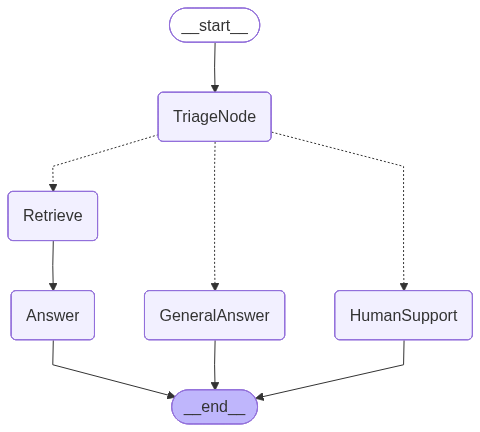

In [14]:
from my_project.rag.graph.agent import chatbot
chatbot